In [40]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [41]:
import pandas as pd

df = pd.read_csv("database.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Shape: (1567, 3)

Columns:
Index(['Unnamed: 0', 'Question', 'Answer'], dtype='object')


,Unnamed: 0,Question,Answer
0,0,1,class Solution {\n public:\n vector<int> twoS...
1,1,2,class Solution {\n public:\n ListNode* addTwo...
2,2,3,class Solution {\n public:\n int lengthOfLong...
3,3,4,class Solution {\n public:\n double findMedia...
4,4,5,class Solution {\n public:\n string longestPa...


In [42]:
df = df.dropna()

df = df.drop_duplicates(
    subset=["Answer"]
)

In [43]:
print(df.shape)

(1564, 3)


In [44]:
code_lengths = df["Answer"].str.len()

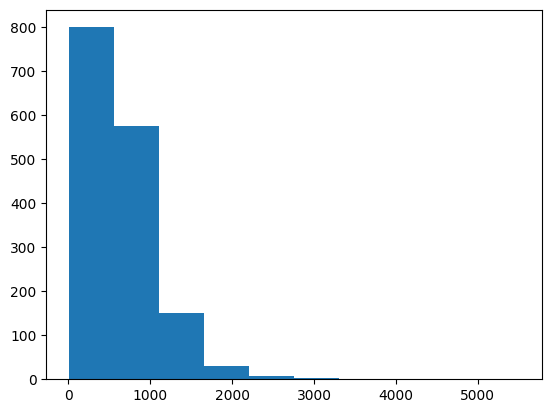

In [45]:
import matplotlib.pyplot as plt

plt.hist(code_lengths)
plt.show()

In [46]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    filters='',
    lower=False
)

In [47]:
tokenizer.fit_on_texts(
    df["Answer"]
)

In [48]:
vocab_size = len(
    tokenizer.word_index
)+1

print(vocab_size)

21226


In [49]:
input_sequences = []

for code in df["Answer"]:

    token_list = tokenizer.texts_to_sequences([code])[0]

    for i in range(1, len(token_list)):
        seq = token_list[:i+1]
        input_sequences.append(seq)

print("Total Sequences:", len(input_sequences))

Total Sequences: 140611


In [50]:
max_len = max(len(seq) for seq in input_sequences)

print(max_len)

692


In [51]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [52]:
print(padded.shape)

(140611, 692)


In [53]:
import numpy as np

padded = np.array(padded)

X = padded[:, :-1]
y = padded[:, -1]

print(X.shape)
print(y.shape)

(140611, 691)
(140611,)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(126549, 691)
(14062, 691)


In [55]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    tf.keras.layers.GRU(
        128
    ),

    tf.keras.layers.Dense(
        vocab_size,
        activation='softmax'
    )

])

In [56]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [57]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [58]:
model(tf.random.uniform((1, X.shape[1]), maxval=vocab_size, dtype=tf.int32))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (1, 691, 128)          │     2,716,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (1, 128)               │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 21226)             │     2,738,154 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,554,154 (21.19 MB)

 Trainable params: 5,554,154 (21.19 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
MAX_LEN = 200

X = X[:, -MAX_LEN:]

print(X.shape)

(140611, 200)


In [60]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(126549, 200)
(14062, 200)


In [61]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128
)

Epoch 1/5
989/989 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - accuracy: 0.1708 - loss: 6.0723 - val_accuracy: 0.2907 - val_loss: 5.0322
Epoch 2/5
989/989 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.3472 - loss: 4.2921 - val_accuracy: 0.3661 - val_loss: 4.5596
Epoch 3/5
989/989 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.4139 - loss: 3.5438 - val_accuracy: 0.3964 - val_loss: 4.4332
Epoch 4/5
989/989 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.4612 - loss: 3.0217 - val_accuracy: 0.4116 - val_loss: 4.3957
Epoch 5/5
989/989 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.5033 - loss: 2.6056 - val_accuracy: 0.4227 - val_loss: 4.4228


In [62]:
model.save("code_model.keras")

In [63]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [64]:
from google.colab import files

files.download("code_model.keras")
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def predict_next(seed_text):

    token_list = tokenizer.texts_to_sequences(
        [seed_text]
    )[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=200,
        padding='pre'
    )

    pred = np.argmax(
        model.predict(
            token_list,
            verbose=0
        )
    )

    for word, idx in tokenizer.word_index.items():

        if idx == pred:
            return word

    return ""

In [66]:
print(predict_next("vector<int>"))
print(predict_next("for"))
print(predict_next("return"))
print(predict_next("while"))

int)
(int
public:

{



In [67]:
def generate_code(seed, num_words=20):

    for _ in range(num_words):

        nxt = predict_next(seed)

        seed += " " + nxt

    return seed

In [68]:
print(
    generate_code(
        "vector<int>",
        20
    )
)

vector<int> int) : id(n), rank(n) {
 iota(begin(id), end(id), 0);
 }

 void unionByRank(int u, int v) {
 const int i = find(u);



In [69]:
print(predict_next("return"))
print(predict_next("for"))
print(predict_next("vector<int>"))

public:

(int
int)


In [70]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            128,
            return_sequences=True
        )
    ),

    tf.keras.layers.GRU(
        64
    ),

    tf.keras.layers.Dense(
        vocab_size,
        activation='softmax'
    )
])

In [71]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
model.build(input_shape=(None, 200))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     2,716,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 21226)          │     1,379,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,421,610 (16.87 MB)

 Trainable params: 4,421,610 (16.87 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128
)

Epoch 1/5
989/989 ━━━━━━━━━━━━━━━━━━━━ 54s 50ms/step - accuracy: 0.0754 - loss: 6.6960 - val_accuracy: 0.1616 - val_loss: 5.9539
Epoch 2/5
989/989 ━━━━━━━━━━━━━━━━━━━━ 50s 51ms/step - accuracy: 0.2600 - loss: 5.0992 - val_accuracy: 0.2927 - val_loss: 5.1168
Epoch 3/5
989/989 ━━━━━━━━━━━━━━━━━━━━ 52s 53ms/step - accuracy: 0.3343 - loss: 4.3217 - val_accuracy: 0.3318 - val_loss: 4.8902
Epoch 4/5
989/989 ━━━━━━━━━━━━━━━━━━━━ 54s 54ms/step - accuracy: 0.3788 - loss: 3.8801 - val_accuracy: 0.3555 - val_loss: 4.8212
Epoch 5/5
989/989 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.4113 - loss: 3.5533 - val_accuracy: 0.3722 - val_loss: 4.7769


In [74]:
print(
    generate_code(
        "vector<int>",
        50
    )
)

vector<int> dfs(const grid) {
 int ans = 0;
 int ans = 0;
 int i = 0;
 int r = 0; // # of the = A[l + 1, i + 1, i + 1, i + 1, i + 1, i + 1, i + 1, i + 1, i +


In [75]:
print(
    generate_code(
        "for",
        50
    )
)

for Solution {
 public:
 int maxProfit(vector<int>& arr) {
 int ans = 0;
 int ans = 0;
 int i = 0;
 int r = 0; // # of the = A[l + 1, i + 1, i + 1, i + 1, i + 1, i + 1, i + 1, i


In [76]:
print(
    generate_code(
        "return",
        50
    )
)

return TrieNode {
 vector<shared_ptr<TrieNode>> children;
 int i = 0;
 int r = 0;
 int ans = 0;
 int ans = 0;
 int i = 0;
 for (int j = 0; j < n; ++j)
 if (nums[i] > 0)
 return false;
 if (nums[i] > 0)
 return false;
 if (nums[i] == 0)
 return


In [77]:
model.save("final_code_model.keras")

In [78]:
import pickle

with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

In [79]:
from google.colab import files

files.download("final_code_model.keras")
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
from google.colab import files

files.download("final_code_model.keras")
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>